# Wifi-aanwezigheidsanalyse — groepswerken versus gewone vakken

Deze notebook generaliseert de werkende aanpak uit de notebook voor **System Engineering Lab**.

Dezelfde basisprincipes blijven behouden:

- lesmomenten komen uit `FactLecture`;
- exacte start- en eindtijden komen uit `DimDate` en `DimTime`;
- wifi-observaties komen uit `DEP2_staging.dbo.FactWifiConnection`;
- studenten worden via `BridgeUserSubgroup` aan de ingeplande subgroepen gekoppeld;
- een student telt per sessie maximaal één keer mee;
- aanwezigheid wordt berekend als unieke aanwezige studenten gedeeld door unieke verwachte studenten.

De analyse wordt afzonderlijk uitgevoerd voor:

1. **groepswerken** uit `group_projects.csv`;
2. **gewone vakken** uit `non_group_projects.csv`.

> Voor System Engineering Lab werd een vaste sessiegroep per student afgeleid omdat alle studenten administratief aan meerdere blokken konden voorkomen. Voor de algemene analyse wordt de populatie per effectief ingeplande subgroep gebruikt. Dit maakt dezelfde wifi-tijdsvensterlogica bruikbaar voor alle vakken, inclusief gewone lessen.


In [47]:
import pandas as pd
import numpy as np
import sqlalchemy as sa
import matplotlib.pyplot as plt
from pathlib import Path
import re
import unicodedata
import warnings

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 1. Instellingen

In [48]:
server = "localhost\\MSSQLSERVER2019"
main_database = "DEP2"
staging_database = "DEP2_staging"
driver = "ODBC Driver 17 for SQL Server"

REPO_ROOT = Path(
    r"D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12"
)

GROUP_COURSES_FILE = (
    REPO_ROOT / "data" / "cleaned" / "SplitCourses" / "group_projects.csv"
)

REGULAR_COURSES_FILE = (
    REPO_ROOT / "data" / "cleaned" / "SplitCourses" / "non_group_projects.csv"
)

OUTPUT_DIR = (
    REPO_ROOT / "data" / "processed" / "CourseTypeAnalysis"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROGRAM_NAMES = [
    "PBA-TIN-TI",
    "PBA-TIN2-TI",
]

START_DATE = "2025-09-01"
END_DATE = "2026-06-30"

# Opeenvolgende lesblokken van hetzelfde vak op dezelfde dag worden
# samengevoegd wanneer de pauze maximaal deze duur heeft.
MAX_BREAK_MINUTES = 30

# Zeer korte blokken worden niet als volwaardige sessie beschouwd.
MIN_SESSION_DURATION_MINUTES = 30

engine = sa.create_engine(
    f"mssql+pyodbc://@{server}/{main_database}"
    f"?driver={driver}&trusted_connection=yes&TrustServerCertificate=yes"
)

print("Groepswerkenbestand:", GROUP_COURSES_FILE)
print("Gewone vakkenbestand:", REGULAR_COURSES_FILE)
print("Uitvoermap:", OUTPUT_DIR)

Groepswerkenbestand: D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12\data\cleaned\SplitCourses\group_projects.csv
Gewone vakkenbestand: D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12\data\cleaned\SplitCourses\non_group_projects.csv
Uitvoermap: D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12\data\processed\CourseTypeAnalysis


## 2. Hulpfuncties

In [49]:
def normalize_text(value) -> str:
    if pd.isna(value):
        return ""

    text = unicodedata.normalize("NFKD", str(value))
    text = "".join(
        character
        for character in text
        if not unicodedata.combining(character)
    )
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9]+", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def assign_session_ids(day_blocks: pd.DataFrame) -> pd.DataFrame:
    """
    Voegt opeenvolgende of overlappende tijdsblokken van hetzelfde vak
    op dezelfde dag samen tot één sessie.
    """
    day_blocks = day_blocks.sort_values(
        ["StartDateTime", "EndDateTime"]
    ).copy()

    session_number = 0
    current_end = None
    assigned = []

    for row in day_blocks.itertuples(index=False):
        if current_end is None:
            session_number += 1
            current_end = row.EndDateTime
        else:
            gap_minutes = (
                row.StartDateTime - current_end
            ).total_seconds() / 60

            if gap_minutes <= MAX_BREAK_MINUTES:
                current_end = max(current_end, row.EndDateTime)
            else:
                session_number += 1
                current_end = row.EndDateTime

        assigned.append(session_number)

    day_blocks["SessionNumberOnDay"] = assigned
    return day_blocks


def descriptive_metrics(group: pd.DataFrame) -> pd.Series:
    rates = group["AttendanceRate"].dropna()

    total_expected = group["ExpectedStudents"].sum()
    total_present = group["PresentStudents"].sum()

    return pd.Series({
        "SessionCount": group["SessionID"].nunique(),
        "ValidAttendanceRates": rates.count(),
        "ExpectedStudentsSum": total_expected,
        "PresentStudentsSum": total_present,
        "WeightedAttendanceRate": (
            total_present / total_expected
            if total_expected > 0 else np.nan
        ),
        "MeanAttendanceRate": rates.mean(),
        "MedianAttendanceRate": rates.median(),
        "StandardDeviation": rates.std(),
        "Variance": rates.var(),
        "Minimum": rates.min(),
        "Percentile10": rates.quantile(0.10),
        "Quartile1": rates.quantile(0.25),
        "Quartile3": rates.quantile(0.75),
        "Percentile90": rates.quantile(0.90),
        "Maximum": rates.max(),
        "InterquartileRange": (
            rates.quantile(0.75) - rates.quantile(0.25)
            if not rates.empty else np.nan
        ),
        "CoefficientOfVariation": (
            rates.std() / rates.mean()
            if rates.count() > 1 and rates.mean() != 0
            else np.nan
        ),
        "MeanExpectedStudents": group["ExpectedStudents"].mean(),
        "MedianExpectedStudents": group["ExpectedStudents"].median(),
        "MeanPresentStudents": group["PresentStudents"].mean(),
        "MedianPresentStudents": group["PresentStudents"].median(),
    })

## 3. Classificatie van de vakken inlezen

In [50]:
group_courses = pd.read_csv(GROUP_COURSES_FILE)
regular_courses = pd.read_csv(REGULAR_COURSES_FILE)

required_column = "title"

if required_column not in group_courses.columns:
    raise ValueError(
        f"{GROUP_COURSES_FILE.name} bevat geen kolom '{required_column}'."
    )

if required_column not in regular_courses.columns:
    raise ValueError(
        f"{REGULAR_COURSES_FILE.name} bevat geen kolom '{required_column}'."
    )

group_titles = {
    normalize_text(value)
    for value in group_courses["title"].dropna()
}

regular_titles = {
    normalize_text(value)
    for value in regular_courses["title"].dropna()
}

overlap = group_titles & regular_titles

if overlap:
    raise ValueError(
        f"{len(overlap)} titels staan in beide bestanden: "
        f"{sorted(overlap)[:10]}"
    )

print(f"Groepswerken: {len(group_titles)} unieke titels")
print(f"Gewone vakken: {len(regular_titles)} unieke titels")
print(f"Totaal geclassificeerd: {len(group_titles | regular_titles)}")

Groepswerken: 15 unieke titels
Gewone vakken: 76 unieke titels
Totaal geclassificeerd: 91


## 4. Alle relevante roosterdata ophalen

In [51]:
program_placeholders = ", ".join(["?"] * len(PROGRAM_NAMES))

schedule_query = f"""
SELECT
    fl.LectureID,
    fl.DateKey,
    fl.FromTimeKey,
    fl.UntilTimeKey,
    fl.SubgroupKey,
    d.FullDate,
    d.NumberSemester,
    tf.Hour AS FromHour,
    tf.Minutes AS FromMinutes,
    tf.Seconds AS FromSeconds,
    tu.Hour AS UntilHour,
    tu.Minutes AS UntilMinutes,
    tu.Seconds AS UntilSeconds,
    c.ClassName,
    sg.SubgroupCode,
    sg.ProgramName
FROM [{main_database}].dbo.FactLecture fl
JOIN [{main_database}].dbo.DimDate d
    ON fl.DateKey = d.DateKey
JOIN [{main_database}].dbo.DimTime tf
    ON fl.FromTimeKey = tf.TimeKey
JOIN [{main_database}].dbo.DimTime tu
    ON fl.UntilTimeKey = tu.TimeKey
JOIN [{main_database}].dbo.DimClass c
    ON fl.ClassKey = c.ClassKey
JOIN [{main_database}].dbo.DimSubgroup sg
    ON fl.SubgroupKey = sg.SubgroupKey
WHERE sg.ProgramName IN ({program_placeholders})
  AND d.FullDate BETWEEN ? AND ?
ORDER BY
    d.FullDate,
    c.ClassName,
    tf.Hour,
    tf.Minutes,
    sg.SubgroupCode;
"""

schedule_raw = pd.read_sql(
    schedule_query,
    engine,
    params=(
        *PROGRAM_NAMES,
        START_DATE,
        END_DATE,
    ),
)

schedule_raw["FullDate"] = pd.to_datetime(
    schedule_raw["FullDate"]
)

schedule_raw["NormalizedClassName"] = (
    schedule_raw["ClassName"].map(normalize_text)
)

schedule_raw["LessonType"] = np.select(
    [
        schedule_raw["NormalizedClassName"].isin(group_titles),
        schedule_raw["NormalizedClassName"].isin(regular_titles),
    ],
    [
        "Groepswerk",
        "Gewoon vak",
    ],
    default="Niet gekoppeld",
)

print(f"Factrijen: {len(schedule_raw):,}")
print(f"Unieke LectureID's: {schedule_raw['LectureID'].nunique():,}")
print(f"Unieke vaknamen: {schedule_raw['ClassName'].nunique():,}")
print(f"Lesdagen: {schedule_raw['FullDate'].nunique():,}")
print(f"Subgroepen: {schedule_raw['SubgroupKey'].nunique():,}")

display(
    schedule_raw["LessonType"]
    .value_counts(dropna=False)
    .rename_axis("LessonType")
    .reset_index(name="FactRows")
)

schedule_raw.head(20)

Factrijen: 5,587
Unieke LectureID's: 3,353
Unieke vaknamen: 59
Lesdagen: 133
Subgroepen: 278


,LessonType,FactRows
0,Gewoon vak,4310
1,Groepswerk,1265
2,Niet gekoppeld,12


,LectureID,DateKey,FromTimeKey,UntilTimeKey,SubgroupKey,FullDate,NumberSemester,FromHour,FromMinutes,FromSeconds,UntilHour,UntilMinutes,UntilSeconds,ClassName,SubgroupCode,ProgramName,NormalizedClassName,LessonType
0,396276,20250922,91500,101500,6018318,2025-09-22,1,9,15,0,10,15,0,Business analysis,PBA-TIN-TI/3A3,PBA-TIN-TI,business analysis,Gewoon vak
1,386394,20250922,91500,101500,5816398,2025-09-22,1,9,15,0,10,15,0,Business analysis,PBA-TIN-TI/3C2,PBA-TIN-TI,business analysis,Gewoon vak
2,386394,20250922,91500,101500,5915911,2025-09-22,1,9,15,0,10,15,0,Business analysis,PBA-TIN-TI/3E,PBA-TIN-TI,business analysis,Gewoon vak
3,396261,20250922,103000,123000,5753006,2025-09-22,1,10,30,0,12,30,0,Business analysis,PBA-TIN-TI/3A1,PBA-TIN-TI,business analysis,Gewoon vak
4,396261,20250922,103000,123000,5872325,2025-09-22,1,10,30,0,12,30,0,Business analysis,PBA-TIN-TI/3A2,PBA-TIN-TI,business analysis,Gewoon vak
5,396290,20250922,103000,123000,6018318,2025-09-22,1,10,30,0,12,30,0,Business analysis,PBA-TIN-TI/3A3,PBA-TIN-TI,business analysis,Gewoon vak
6,386407,20250922,103000,123000,5816398,2025-09-22,1,10,30,0,12,30,0,Business analysis,PBA-TIN-TI/3C2,PBA-TIN-TI,business analysis,Gewoon vak
7,386407,20250922,103000,123000,5915911,2025-09-22,1,10,30,0,12,30,0,Business analysis,PBA-TIN-TI/3E,PBA-TIN-TI,business analysis,Gewoon vak
8,387588,20250922,103000,123000,5937306,2025-09-22,1,10,30,0,12,30,0,Classic Computer Science Algorithms,PBA-TIN-TI/2E1,PBA-TIN-TI,classic computer science algorithms,Gewoon vak
9,387588,20250922,103000,123000,5796254,2025-09-22,1,10,30,0,12,30,0,Classic Computer Science Algorithms,PBA-TIN-TI/2F,PBA-TIN-TI,classic computer science algorithms,Gewoon vak


## 5. Niet-gekoppelde vaknamen controleren

In [52]:
unmatched_titles = (
    schedule_raw.loc[
        schedule_raw["LessonType"] == "Niet gekoppeld",
        ["ClassName", "NormalizedClassName"],
    ]
    .drop_duplicates()
    .sort_values("ClassName")
)

print(f"Niet-gekoppelde unieke titels: {len(unmatched_titles)}")
display(unmatched_titles.head(100))

unmatched_titles.to_csv(
    OUTPUT_DIR / "unmatched_course_titles.csv",
    index=False,
    encoding="utf-8-sig",
)

Niet-gekoppelde unieke titels: 1


,ClassName,NormalizedClassName
37,A.I. for the bachelorstudent,a i for the bachelorstudent


## 6. Exacte lesmomenten opbouwen

In [53]:
schedule = schedule_raw[
    schedule_raw["LessonType"].isin(
        ["Groepswerk", "Gewoon vak"]
    )
].copy()

schedule["StartDateTime"] = (
    schedule["FullDate"]
    + pd.to_timedelta(schedule["FromHour"], unit="h")
    + pd.to_timedelta(schedule["FromMinutes"], unit="m")
    + pd.to_timedelta(schedule["FromSeconds"], unit="s")
)

schedule["EndDateTime"] = (
    schedule["FullDate"]
    + pd.to_timedelta(schedule["UntilHour"], unit="h")
    + pd.to_timedelta(schedule["UntilMinutes"], unit="m")
    + pd.to_timedelta(schedule["UntilSeconds"], unit="s")
)

time_blocks = (
    schedule[[
        "ClassName",
        "NormalizedClassName",
        "LessonType",
        "FullDate",
        "StartDateTime",
        "EndDateTime",
    ]]
    .drop_duplicates()
    .sort_values([
        "ClassName",
        "FullDate",
        "StartDateTime",
        "EndDateTime",
    ])
    .reset_index(drop=True)
)

print(f"Unieke tijdsblokken: {len(time_blocks):,}")
time_blocks.head(20)

Unieke tijdsblokken: 2,612


,ClassName,NormalizedClassName,LessonType,FullDate,StartDateTime,EndDateTime
0,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-01,2025-10-01 18:00:00,2025-10-01 20:00:00
1,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-08,2025-10-08 18:00:00,2025-10-08 20:00:00
2,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-15,2025-10-15 18:00:00,2025-10-15 20:00:00
3,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-22,2025-10-22 18:00:00,2025-10-22 20:00:00
4,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-29,2025-10-29 18:00:00,2025-10-29 20:00:00
5,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-05,2025-11-05 18:00:00,2025-11-05 20:00:00
6,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-12,2025-11-12 18:00:00,2025-11-12 20:00:00
7,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-19,2025-11-19 18:00:00,2025-11-19 20:00:00
8,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-26,2025-11-26 18:00:00,2025-11-26 20:00:00
9,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-12-03,2025-12-03 18:00:00,2025-12-03 20:00:00


## 7. Opeenvolgende blokken per vak samenvoegen tot sessies

In [54]:
processed_groups = []

for (_, _), day_blocks in time_blocks.groupby(
    ["ClassName", "FullDate"],
    sort=True,
):
    processed_groups.append(
        assign_session_ids(day_blocks)
    )

if not processed_groups:
    raise ValueError(
        "Er zijn geen geclassificeerde tijdsblokken om te analyseren."
    )

time_blocks = pd.concat(
    processed_groups,
    ignore_index=True,
)

time_blocks["SessionID"] = (
    time_blocks["NormalizedClassName"]
    + "_"
    + time_blocks["FullDate"].dt.strftime("%Y%m%d")
    + "_"
    + time_blocks["SessionNumberOnDay"].astype(str)
)

sessions = (
    time_blocks
    .groupby([
        "ClassName",
        "NormalizedClassName",
        "LessonType",
        "FullDate",
        "SessionID",
    ])
    .agg(
        SessionStart=("StartDateTime", "min"),
        SessionEnd=("EndDateTime", "max"),
        NumberOfTimeBlocks=("StartDateTime", "nunique"),
    )
    .reset_index()
)

sessions["SessionDurationMinutes"] = (
    sessions["SessionEnd"] - sessions["SessionStart"]
).dt.total_seconds() / 60

sessions = sessions[
    sessions["SessionDurationMinutes"]
    >= MIN_SESSION_DURATION_MINUTES
].copy()

sessions["WeekdayName"] = sessions["FullDate"].dt.day_name()
sessions["SessionStartTime"] = sessions["SessionStart"].dt.strftime("%H:%M")
sessions["SessionEndTime"] = sessions["SessionEnd"].dt.strftime("%H:%M")
sessions["SessionSlot"] = (
    sessions["WeekdayName"]
    + " "
    + sessions["SessionStartTime"]
    + "-"
    + sessions["SessionEndTime"]
)

print(f"Afgeleide sessies: {len(sessions):,}")
print(f"Groepswerksessies: {(sessions['LessonType'] == 'Groepswerk').sum():,}")
print(f"Gewone vaksessies: {(sessions['LessonType'] == 'Gewoon vak').sum():,}")

sessions.head(20)

Afgeleide sessies: 1,801
Groepswerksessies: 152
Gewone vaksessies: 1,649


,ClassName,NormalizedClassName,LessonType,FullDate,SessionID,SessionStart,SessionEnd,NumberOfTimeBlocks,SessionDurationMinutes,WeekdayName,SessionStartTime,SessionEndTime,SessionSlot
0,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-01,a i voor de bachelorstudent_20251001_1,2025-10-01 18:00:00,2025-10-01 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00
1,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-08,a i voor de bachelorstudent_20251008_1,2025-10-08 18:00:00,2025-10-08 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00
2,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-15,a i voor de bachelorstudent_20251015_1,2025-10-15 18:00:00,2025-10-15 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00
3,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-22,a i voor de bachelorstudent_20251022_1,2025-10-22 18:00:00,2025-10-22 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00
4,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-29,a i voor de bachelorstudent_20251029_1,2025-10-29 18:00:00,2025-10-29 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00
5,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-05,a i voor de bachelorstudent_20251105_1,2025-11-05 18:00:00,2025-11-05 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00
6,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-12,a i voor de bachelorstudent_20251112_1,2025-11-12 18:00:00,2025-11-12 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00
7,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-19,a i voor de bachelorstudent_20251119_1,2025-11-19 18:00:00,2025-11-19 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00
8,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-26,a i voor de bachelorstudent_20251126_1,2025-11-26 18:00:00,2025-11-26 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00
9,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-12-03,a i voor de bachelorstudent_20251203_1,2025-12-03 18:00:00,2025-12-03 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00


## 8. Roosterblokken en subgroepen aan sessies koppelen

In [55]:
session_block_links = (
    schedule[[
        "LectureID",
        "ClassName",
        "NormalizedClassName",
        "LessonType",
        "FullDate",
        "StartDateTime",
        "EndDateTime",
        "SubgroupKey",
        "SubgroupCode",
        "ProgramName",
    ]]
    .merge(
        time_blocks[[
            "ClassName",
            "FullDate",
            "StartDateTime",
            "EndDateTime",
            "SessionID",
        ]],
        on=[
            "ClassName",
            "FullDate",
            "StartDateTime",
            "EndDateTime",
        ],
        how="inner",
        validate="many_to_one",
    )
)

session_subgroups = (
    session_block_links[[
        "SessionID",
        "SubgroupKey",
        "SubgroupCode",
    ]]
    .drop_duplicates()
)

print(f"Sessie-subgroepkoppelingen: {len(session_subgroups):,}")
print(
    f"Sessies met minstens één subgroep: "
    f"{session_subgroups['SessionID'].nunique():,}"
)

session_subgroups.head(20)

Sessie-subgroepkoppelingen: 4,372
Sessies met minstens één subgroep: 1,801


,SessionID,SubgroupKey,SubgroupCode
0,business analysis_20250922_1,6018318,PBA-TIN-TI/3A3
1,business analysis_20250922_1,5816398,PBA-TIN-TI/3C2
2,business analysis_20250922_1,5915911,PBA-TIN-TI/3E
3,business analysis_20250922_1,5753006,PBA-TIN-TI/3A1
4,business analysis_20250922_1,5872325,PBA-TIN-TI/3A2
8,classic computer science algorithms_20250922_1,5937306,PBA-TIN-TI/2E1
9,classic computer science algorithms_20250922_1,5796254,PBA-TIN-TI/2F
10,computer systems_20250922_1,5879555,PBA-TIN-TI/1H
11,costing_20250922_1,5807008,PBA-TIN-TI/2A1
12,costing_20250922_1,5787963,PBA-TIN-TI/2B


## 9. Studenten per subgroep ophalen

In [56]:
students_query = f"""
SELECT DISTINCT
    bus.UserKey,
    bus.SubgroupKey,
    du.UserName,
    sg.SubgroupCode,
    sg.ProgramName
FROM [{staging_database}].dbo.BridgeUserSubgroup bus
JOIN [{staging_database}].dbo.DimUser du
    ON bus.UserKey = du.UserKey
JOIN [{main_database}].dbo.DimSubgroup sg
    ON bus.SubgroupKey = sg.SubgroupKey
WHERE sg.ProgramName IN ({program_placeholders});
"""

students_by_subgroup = pd.read_sql(
    students_query,
    engine,
    params=tuple(PROGRAM_NAMES),
)

print(f"Student-subgroepkoppelingen: {len(students_by_subgroup):,}")
print(f"Unieke studenten: {students_by_subgroup['UserKey'].nunique():,}")
print(f"Unieke subgroepen: {students_by_subgroup['SubgroupKey'].nunique():,}")

students_by_subgroup.head(20)

Student-subgroepkoppelingen: 12,135
Unieke studenten: 1,771
Unieke subgroepen: 400


,UserKey,SubgroupKey,UserName,SubgroupCode,ProgramName
0,1,5787959,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
1,1,5787960,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
2,1,5787961,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
3,1,5787962,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
4,1,5787963,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
5,1,5787964,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
6,1,5787973,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2B,PBA-TIN-TI
7,1,5872107,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2A3,PBA-TIN-TI
8,1,5872110,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2A3,PBA-TIN-TI
9,1,5872111,enc_bjWC-o2rDStqb0A8VjXzjnYvtxhnHNGFEqk-mxA,PBA-TIN-TI/2A3,PBA-TIN-TI


## 10. Verwachte studenten per sessie bepalen

In [57]:
expected_student_links = (
    session_subgroups
    .merge(
        students_by_subgroup[[
            "SubgroupKey",
            "UserKey",
        ]],
        on="SubgroupKey",
        how="left",
    )
    .dropna(subset=["UserKey"])
    .drop_duplicates(
        subset=["SessionID", "UserKey"]
    )
)

expected_by_session = (
    expected_student_links
    .groupby("SessionID", as_index=False)
    .agg(
        ExpectedStudents=("UserKey", "nunique")
    )
)

print(
    f"Sessies met verwachte studenten: "
    f"{expected_by_session['SessionID'].nunique():,}"
)

display(
    expected_by_session["ExpectedStudents"].describe()
)

expected_by_session.head(20)

Sessies met verwachte studenten: 1,801


count   1,801.0000
mean      104.4081
std        82.4059
min         2.0000
25%        51.0000
50%        80.0000
75%       129.0000
max       450.0000
Name: ExpectedStudents, dtype: float64

,SessionID,ExpectedStudents
0,a i voor de bachelorstudent_20251001_1,104
1,a i voor de bachelorstudent_20251008_1,104
2,a i voor de bachelorstudent_20251015_1,104
3,a i voor de bachelorstudent_20251022_1,104
4,a i voor de bachelorstudent_20251029_1,104
5,a i voor de bachelorstudent_20251105_1,104
6,a i voor de bachelorstudent_20251112_1,104
7,a i voor de bachelorstudent_20251119_1,104
8,a i voor de bachelorstudent_20251126_1,104
9,a i voor de bachelorstudent_20251203_1,104


## 11. Wifi-connecties voor alle relevante studenten ophalen

In [58]:
wifi_query = f"""
SELECT DISTINCT
    fwc.UserKey,
    du.UserName,
    fwc.DateKey,
    fwc.TimeKey,
    d.FullDate,
    t.Hour,
    t.Minutes,
    t.Seconds
FROM [{staging_database}].dbo.FactWifiConnection fwc
JOIN [{staging_database}].dbo.DimUser du
    ON fwc.UserKey = du.UserKey
JOIN [{staging_database}].dbo.BridgeUserSubgroup bus
    ON fwc.UserKey = bus.UserKey
JOIN [{main_database}].dbo.DimSubgroup sg
    ON bus.SubgroupKey = sg.SubgroupKey
JOIN [{main_database}].dbo.DimDate d
    ON fwc.DateKey = d.DateKey
JOIN [{main_database}].dbo.DimTime t
    ON fwc.TimeKey = t.TimeKey
WHERE sg.ProgramName IN ({program_placeholders})
  AND d.FullDate BETWEEN ? AND ?;
"""

wifi = pd.read_sql(
    wifi_query,
    engine,
    params=(
        *PROGRAM_NAMES,
        START_DATE,
        END_DATE,
    ),
)

wifi["FullDate"] = pd.to_datetime(wifi["FullDate"])

wifi["WifiDateTime"] = (
    wifi["FullDate"]
    + pd.to_timedelta(wifi["Hour"], unit="h")
    + pd.to_timedelta(wifi["Minutes"], unit="m")
    + pd.to_timedelta(wifi["Seconds"], unit="s")
)

wifi = wifi.drop_duplicates(
    subset=["UserKey", "WifiDateTime"]
)

print(f"Wifi-records: {len(wifi):,}")
print(f"Unieke UserKeys: {wifi['UserKey'].nunique():,}")
print(f"Wifi-dagen: {wifi['FullDate'].nunique():,}")

wifi.head(20)

Wifi-records: 1,402,218
Unieke UserKeys: 1,627
Wifi-dagen: 204


,UserKey,UserName,DateKey,TimeKey,FullDate,Hour,Minutes,Seconds,WifiDateTime
0,398,enc_qELM5meNpeoC2z8sQrI5WE55iCFIna3Yo3QvoNOtiA,20260310,135100,2026-03-10,13,51,0,2026-03-10 13:51:00
1,511,enc_GsVx3ew2H2sTewUp-YDsFiw6x9pW71rll5E-q1X8iAZr,20251212,90500,2025-12-12,9,5,0,2025-12-12 09:05:00
2,608,enc_RKZskhYA-G1t7O8TDfqaO3-1nHF9IejnjfAdHXFbjX...,20251121,104600,2025-11-21,10,46,0,2025-11-21 10:46:00
3,492,enc_MB-FIsCfn5Y5iSNZevhzSNCU0-TIKU5_tZmu9NC-ig,20260304,95600,2026-03-04,9,56,0,2026-03-04 09:56:00
4,407,enc_8q1HLEyIp-UAAbnWQGDPLaNn5ZLUVon-xo84na7lG3s,20260304,105600,2026-03-04,10,56,0,2026-03-04 10:56:00
5,280,enc_p77KOLW8nGVwCR_TNLVS1pUALmOXZDtrf4TaoQwQEw,20260430,95400,2026-04-30,9,54,0,2026-04-30 09:54:00
6,887,enc_yy3cXFcwSIgzltI__0BPLn9xgxshK12XxpA4eNCk0k...,20251021,75500,2025-10-21,7,55,0,2025-10-21 07:55:00
7,878,enc_nAiGYldyyUi-cfC8M7pxayIWP_cWnE_OVE9KW7tCah...,20251021,81500,2025-10-21,8,15,0,2025-10-21 08:15:00
8,631,enc_Nzut6FKd-_NBYSoiiQMxIvKTrBwfd1uuH4F_D3H5JW...,20251029,95100,2025-10-29,9,51,0,2025-10-29 09:51:00
9,165,enc_kapABqD7uuEZG5y6iNzUlmq3PXDqXcgfF9TWTlA,20260325,74200,2026-03-25,7,42,0,2026-03-25 07:42:00


## 12. Wifi-connecties aan sessies koppelen

In [59]:
matched_parts = []

wifi_by_date = {
    date: group
    for date, group in wifi.groupby("FullDate")
}

expected_users_by_session = {
    session_id: set(group["UserKey"].dropna())
    for session_id, group in expected_student_links.groupby("SessionID")
}

for session in sessions.itertuples(index=False):
    day_wifi = wifi_by_date.get(session.FullDate)

    if day_wifi is None or day_wifi.empty:
        continue

    expected_users = expected_users_by_session.get(
        session.SessionID,
        set(),
    )

    if not expected_users:
        continue

    matched = day_wifi[
        day_wifi["UserKey"].isin(expected_users)
        & day_wifi["WifiDateTime"].between(
            session.SessionStart,
            session.SessionEnd,
            inclusive="both",
        )
    ][[
        "UserKey",
        "UserName",
        "WifiDateTime",
    ]].copy()

    if matched.empty:
        continue

    matched["SessionID"] = session.SessionID
    matched["FullDate"] = session.FullDate
    matched["ClassName"] = session.ClassName
    matched["LessonType"] = session.LessonType
    matched["SessionStart"] = session.SessionStart
    matched["SessionEnd"] = session.SessionEnd

    matched_parts.append(matched)

session_wifi = (
    pd.concat(matched_parts, ignore_index=True)
    if matched_parts
    else pd.DataFrame(
        columns=[
            "UserKey",
            "UserName",
            "WifiDateTime",
            "SessionID",
            "FullDate",
            "ClassName",
            "LessonType",
            "SessionStart",
            "SessionEnd",
        ]
    )
)

print(f"Wifi-records binnen sessies: {len(session_wifi):,}")
print(
    f"Unieke gebruikers binnen sessies: "
    f"{session_wifi['UserKey'].nunique():,}"
)

session_wifi.head(20)

Wifi-records binnen sessies: 759,759
Unieke gebruikers binnen sessies: 1,411


,UserKey,UserName,WifiDateTime,SessionID,FullDate,ClassName,LessonType,SessionStart,SessionEnd
0,2868,u_203996802484f8f3e9a2fcf28362dec2cac472f34151...,2025-10-01 18:14:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00
1,2868,u_203996802484f8f3e9a2fcf28362dec2cac472f34151...,2025-10-01 18:04:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00
2,11974,u_03f8a8f1034dabe695dc7d25faff36e49b1e04fec78a...,2025-10-01 18:04:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00
3,12002,u_96f0eae7f29c1c02ac7b8cf5feb15c234b4b5780600d...,2025-10-01 18:14:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00
4,11998,u_d81ccedd5922d7e2bad336ca86dbde351361369bc093...,2025-10-01 18:04:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00
5,9813,u_166875a66b7f61666051b1b9552853d81296df3d17a8...,2025-10-01 18:04:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00
6,5719,u_19bcc91b711010d10a189da159aa573854c8b5fbc15b...,2025-10-01 18:14:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00
7,11971,u_66067706d81e1c22ac1f34b7e8f2dfcbe9a091325c5d...,2025-10-01 18:09:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00
8,8061,u_5f429fb35cd4c5c3f65bd0b7e68224f09c72e0b42f63...,2025-10-01 18:14:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00
9,12802,u_94470f058d2cd54a9fa8a4ea838ab5d8b60d99b0e0ed...,2025-10-01 18:04:00,a i voor de bachelorstudent_20251001_1,2025-10-01,A.I. voor de bachelorstudent,Gewoon vak,2025-10-01 18:00:00,2025-10-01 20:00:00


## 13. Eén aanwezigheid per gebruiker per sessie

In [60]:
student_session_presence = (
    session_wifi[[
        "UserKey",
        "SessionID",
    ]]
    .drop_duplicates(
        subset=["UserKey", "SessionID"]
    )
)

present_by_session = (
    student_session_presence
    .groupby("SessionID", as_index=False)
    .agg(
        PresentStudents=("UserKey", "nunique")
    )
)

print(
    f"Sessies met minstens één aanwezige student: "
    f"{present_by_session['SessionID'].nunique():,}"
)

present_by_session.head(20)

Sessies met minstens één aanwezige student: 1,594


,SessionID,PresentStudents
0,a i voor de bachelorstudent_20251001_1,15
1,a i voor de bachelorstudent_20251008_1,8
2,a i voor de bachelorstudent_20251015_1,24
3,a i voor de bachelorstudent_20251022_1,4
4,a i voor de bachelorstudent_20251029_1,17
5,a i voor de bachelorstudent_20251105_1,34
6,a i voor de bachelorstudent_20251112_1,20
7,a i voor de bachelorstudent_20251119_1,20
8,a i voor de bachelorstudent_20251126_1,7
9,a i voor de bachelorstudent_20251203_1,17


## 14. Definitieve aanwezigheidsdataset

In [61]:
session_results = (
    sessions
    .merge(
        expected_by_session,
        on="SessionID",
        how="left",
        validate="one_to_one",
    )
    .merge(
        present_by_session,
        on="SessionID",
        how="left",
        validate="one_to_one",
    )
)

session_results["ExpectedStudents"] = (
    session_results["ExpectedStudents"]
    .fillna(0)
    .astype(int)
)

session_results["PresentStudents"] = (
    session_results["PresentStudents"]
    .fillna(0)
    .astype(int)
)

session_results["AttendanceRate"] = np.where(
    session_results["ExpectedStudents"] > 0,
    session_results["PresentStudents"]
    / session_results["ExpectedStudents"],
    np.nan,
)

session_results["AttendancePercentage"] = (
    session_results["AttendanceRate"] * 100
)

valid_session_results = session_results[
    session_results["ExpectedStudents"] > 0
].copy()

print(f"Alle sessies: {len(session_results):,}")
print(f"Sessies met verwachte studenten: {len(valid_session_results):,}")
print(
    f"Sessies zonder verwachte studenten: "
    f"{(session_results['ExpectedStudents'] == 0).sum():,}"
)

print("\nExpectedStudents:")
display(valid_session_results["ExpectedStudents"].describe())

print("\nPresentStudents:")
display(valid_session_results["PresentStudents"].describe())

print("\nAttendanceRate:")
display(valid_session_results["AttendanceRate"].describe())

valid_session_results.head(30)

Alle sessies: 1,801
Sessies met verwachte studenten: 1,801
Sessies zonder verwachte studenten: 0

ExpectedStudents:


count   1,801.0000
mean      104.4081
std        82.4059
min         2.0000
25%        51.0000
50%        80.0000
75%       129.0000
max       450.0000
Name: ExpectedStudents, dtype: float64


PresentStudents:


count   1,801.0000
mean       21.6446
std        24.2396
min         0.0000
25%         5.0000
50%        15.0000
75%        29.0000
max       147.0000
Name: PresentStudents, dtype: float64


AttendanceRate:


count   1,801.0000
mean        0.1992
std         0.1395
min         0.0000
25%         0.0886
50%         0.1952
75%         0.2944
max         0.7692
Name: AttendanceRate, dtype: float64

,ClassName,NormalizedClassName,LessonType,FullDate,SessionID,SessionStart,SessionEnd,NumberOfTimeBlocks,SessionDurationMinutes,WeekdayName,SessionStartTime,SessionEndTime,SessionSlot,ExpectedStudents,PresentStudents,AttendanceRate,AttendancePercentage
0,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-01,a i voor de bachelorstudent_20251001_1,2025-10-01 18:00:00,2025-10-01 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,15,0.1442,14.4231
1,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-08,a i voor de bachelorstudent_20251008_1,2025-10-08 18:00:00,2025-10-08 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,8,0.0769,7.6923
2,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-15,a i voor de bachelorstudent_20251015_1,2025-10-15 18:00:00,2025-10-15 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,24,0.2308,23.0769
3,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-22,a i voor de bachelorstudent_20251022_1,2025-10-22 18:00:00,2025-10-22 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,4,0.0385,3.8462
4,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-10-29,a i voor de bachelorstudent_20251029_1,2025-10-29 18:00:00,2025-10-29 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,17,0.1635,16.3462
5,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-05,a i voor de bachelorstudent_20251105_1,2025-11-05 18:00:00,2025-11-05 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,34,0.3269,32.6923
6,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-12,a i voor de bachelorstudent_20251112_1,2025-11-12 18:00:00,2025-11-12 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,20,0.1923,19.2308
7,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-19,a i voor de bachelorstudent_20251119_1,2025-11-19 18:00:00,2025-11-19 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,20,0.1923,19.2308
8,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-11-26,a i voor de bachelorstudent_20251126_1,2025-11-26 18:00:00,2025-11-26 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,7,0.0673,6.7308
9,A.I. voor de bachelorstudent,a i voor de bachelorstudent,Gewoon vak,2025-12-03,a i voor de bachelorstudent_20251203_1,2025-12-03 18:00:00,2025-12-03 20:00:00,1,120.0000,Wednesday,18:00,20:00,Wednesday 18:00-20:00,104,17,0.1635,16.3462


## 15. Algemene metrics per lestype

In [62]:
metric_rows = []

for lesson_type, group in valid_session_results.groupby(
    "LessonType",
    observed=True,
):
    metrics = descriptive_metrics(group).to_dict()
    metric_rows.append({
        "LessonType": lesson_type,
        **metrics,
    })

metrics_by_type = pd.DataFrame(metric_rows)

if not metrics_by_type.empty:
    metrics_by_type = metrics_by_type.sort_values(
        "LessonType"
    ).reset_index(drop=True)

display(metrics_by_type)

metrics_by_type.to_csv(
    OUTPUT_DIR / "metrics_by_lesson_type.csv",
    index=False,
    encoding="utf-8-sig",
)

,LessonType,SessionCount,ValidAttendanceRates,ExpectedStudentsSum,PresentStudentsSum,WeightedAttendanceRate,MeanAttendanceRate,MedianAttendanceRate,StandardDeviation,Variance,Minimum,Percentile10,Quartile1,Quartile3,Percentile90,Maximum,InterquartileRange,CoefficientOfVariation,MeanExpectedStudents,MedianExpectedStudents,MeanPresentStudents,MedianPresentStudents
0,Gewoon vak,"1,649.0000","1,649.0000","156,236.0000","31,633.0000",0.2025,0.1945,0.1894,0.1376,0.0189,0.0000,0.0000,0.0870,0.2857,0.3580,0.7692,0.1988,0.7076,94.7459,78.0000,19.1831,14.0000
1,Groepswerk,152.0000,152.0000,"31,803.0000","7,349.0000",0.2311,0.2503,0.2625,0.1502,0.0226,0.0000,0.0155,0.1312,0.3745,0.4299,0.5000,0.2433,0.6000,209.2303,100.0000,48.3487,35.0000


## 16. Metrics per afzonderlijk vak

In [63]:
course_metric_rows = []

for (lesson_type, class_name), group in valid_session_results.groupby(
    ["LessonType", "ClassName"],
    observed=True,
):
    metrics = descriptive_metrics(group).to_dict()
    course_metric_rows.append({
        "LessonType": lesson_type,
        "ClassName": class_name,
        **metrics,
    })

metrics_by_course = pd.DataFrame(course_metric_rows)

if not metrics_by_course.empty:
    metrics_by_course = (
        metrics_by_course
        .sort_values(
            ["LessonType", "MedianAttendanceRate"],
            ascending=[True, False],
            na_position="last",
        )
        .reset_index(drop=True)
    )

display(metrics_by_course)

metrics_by_course.to_csv(
    OUTPUT_DIR / "metrics_by_course.csv",
    index=False,
    encoding="utf-8-sig",
)

,LessonType,ClassName,SessionCount,ValidAttendanceRates,ExpectedStudentsSum,PresentStudentsSum,WeightedAttendanceRate,MeanAttendanceRate,MedianAttendanceRate,StandardDeviation,Variance,Minimum,Percentile10,Quartile1,Quartile3,Percentile90,Maximum,InterquartileRange,CoefficientOfVariation,MeanExpectedStudents,MedianExpectedStudents,MeanPresentStudents,MedianPresentStudents
0,Gewoon vak,Linux & Data Processing Automation,1.0000,1.0000,2.0000,1.0000,0.5000,0.5000,0.5000,NaN,NaN,0.5000,0.5000,0.5000,0.5000,0.5000,0.5000,0.0000,NaN,2.0000,2.0000,1.0000,1.0000
1,Gewoon vak,Infrastructure Automation,25.0000,25.0000,539.0000,191.0000,0.3544,0.3564,0.4348,0.2307,0.0532,0.0000,0.0000,0.2609,0.5000,0.6335,0.7000,0.2391,0.6471,21.5600,23.0000,7.6400,9.0000
2,Gewoon vak,Databases,25.0000,25.0000,"1,500.0000",552.0000,0.3680,0.3525,0.4032,0.1776,0.0315,0.0000,0.0114,0.2778,0.4778,0.5257,0.5714,0.2000,0.5038,60.0000,35.0000,22.0800,20.0000
3,Gewoon vak,Business & Management,36.0000,36.0000,"7,029.0000","2,005.0000",0.2852,0.2912,0.3282,0.1148,0.0132,0.0000,0.1212,0.2366,0.3702,0.4012,0.4528,0.1337,0.3942,195.2500,233.0000,55.6944,55.5000
4,Gewoon vak,Cybersecurity,13.0000,13.0000,"1,572.0000",425.0000,0.2704,0.2560,0.3023,0.1264,0.0160,0.0000,0.0581,0.1938,0.3333,0.3473,0.4031,0.1395,0.4936,120.9231,129.0000,32.6923,39.0000
5,Gewoon vak,Functional Analysis,38.0000,38.0000,"3,165.0000",835.0000,0.2638,0.2714,0.2961,0.1543,0.0238,0.0000,0.0068,0.1569,0.3781,0.4474,0.5325,0.2212,0.5684,83.2895,77.0000,21.9737,19.0000
6,Gewoon vak,Object-oriented Software Development I,77.0000,77.0000,"11,338.0000","3,028.0000",0.2671,0.2698,0.2953,0.1182,0.0140,0.0000,0.0317,0.2368,0.3333,0.3585,0.7111,0.0965,0.4379,147.2468,153.0000,39.3247,45.0000
7,Gewoon vak,Software Analysis,38.0000,38.0000,"1,856.0000",484.0000,0.2608,0.2451,0.2859,0.2024,0.0409,0.0000,0.0000,0.0000,0.3636,0.4515,0.7273,0.3636,0.8255,48.8421,33.0000,12.7368,3.5000
8,Gewoon vak,Web Development I,35.0000,35.0000,"2,412.0000",590.0000,0.2446,0.2443,0.2647,0.1277,0.0163,0.0000,0.0377,0.1809,0.3300,0.3862,0.5217,0.1491,0.5228,68.9143,53.0000,16.8571,17.0000
9,Gewoon vak,Communication Lab,62.0000,62.0000,"6,454.0000","1,537.0000",0.2381,0.2391,0.2501,0.1079,0.0116,0.0000,0.0807,0.1765,0.3082,0.3719,0.5294,0.1317,0.4512,104.0968,119.0000,24.7903,21.0000


## 17. Rechtstreekse vergelijking

In [64]:
comparison_indexed = metrics_by_type.set_index("LessonType")

if {"Groepswerk", "Gewoon vak"}.issubset(
    comparison_indexed.index
):
    group_row = comparison_indexed.loc["Groepswerk"]
    regular_row = comparison_indexed.loc["Gewoon vak"]

    comparison = pd.DataFrame({
        "Metric": [
            "Gewogen aanwezigheidsgraad",
            "Gemiddelde aanwezigheidsgraad",
            "Mediaan aanwezigheidsgraad",
            "Standaardafwijking",
            "Variantie",
            "Eerste kwartiel",
            "Derde kwartiel",
            "Interkwartielafstand",
            "Aantal sessies",
        ],
        "Groepswerk": [
            group_row["WeightedAttendanceRate"],
            group_row["MeanAttendanceRate"],
            group_row["MedianAttendanceRate"],
            group_row["StandardDeviation"],
            group_row["Variance"],
            group_row["Quartile1"],
            group_row["Quartile3"],
            group_row["InterquartileRange"],
            group_row["SessionCount"],
        ],
        "GewoonVak": [
            regular_row["WeightedAttendanceRate"],
            regular_row["MeanAttendanceRate"],
            regular_row["MedianAttendanceRate"],
            regular_row["StandardDeviation"],
            regular_row["Variance"],
            regular_row["Quartile1"],
            regular_row["Quartile3"],
            regular_row["InterquartileRange"],
            regular_row["SessionCount"],
        ],
    })

    comparison["VerschilGroepswerkMinGewoon"] = (
        comparison["Groepswerk"]
        - comparison["GewoonVak"]
    )

    display(comparison)

    comparison.to_csv(
        OUTPUT_DIR / "group_vs_regular_comparison.csv",
        index=False,
        encoding="utf-8-sig",
    )
else:
    print(
        "Niet beide lestypes bevatten geldige sessies. "
        "Controleer de classificatie en de sessiedata."
    )

,Metric,Groepswerk,GewoonVak,VerschilGroepswerkMinGewoon
0,Gewogen aanwezigheidsgraad,0.2311,0.2025,0.0286
1,Gemiddelde aanwezigheidsgraad,0.2503,0.1945,0.0558
2,Mediaan aanwezigheidsgraad,0.2625,0.1894,0.0732
3,Standaardafwijking,0.1502,0.1376,0.0126
4,Variantie,0.0226,0.0189,0.0036
5,Eerste kwartiel,0.1312,0.0870,0.0442
6,Derde kwartiel,0.3745,0.2857,0.0887
7,Interkwartielafstand,0.2433,0.1988,0.0445
8,Aantal sessies,152.0000,"1,649.0000","-1,497.0000"


## 18. Visualisaties

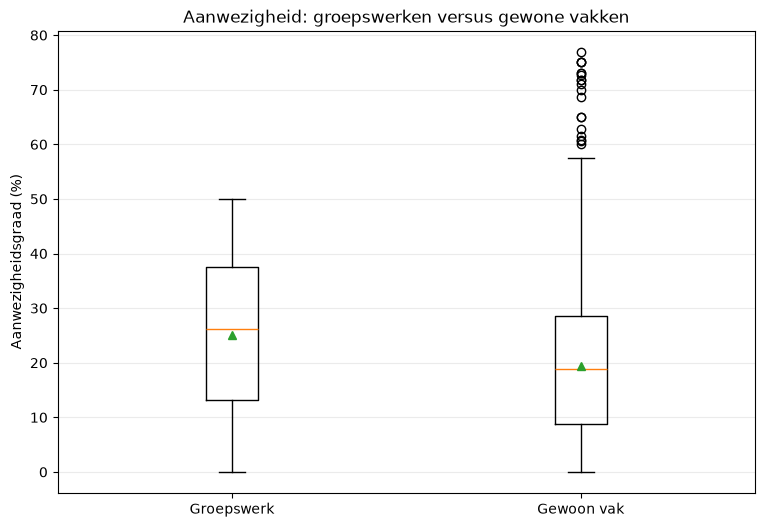

In [65]:
plot_groups = []

for lesson_type in ["Groepswerk", "Gewoon vak"]:
    values = valid_session_results.loc[
        valid_session_results["LessonType"] == lesson_type,
        "AttendancePercentage",
    ].dropna()

    plot_groups.append(values)

plt.figure(figsize=(9, 6))
plt.boxplot(
    plot_groups,
    tick_labels=["Groepswerk", "Gewoon vak"],
    showmeans=True,
)
plt.ylabel("Aanwezigheidsgraad (%)")
plt.title("Aanwezigheid: groepswerken versus gewone vakken")
plt.grid(axis="y", alpha=0.25)
plt.show()

In [66]:
trend_data = valid_session_results.copy()

# Maandag als start van elke week
trend_data["WeekStart"] = (
    trend_data["FullDate"]
    - pd.to_timedelta(
        trend_data["FullDate"].dt.weekday,
        unit="D",
    )
)

# Gewogen aanwezigheid per week en lestype
weekly_trend = (
    trend_data
    .groupby(
        ["WeekStart", "LessonType"],
        observed=True,
        as_index=False,
    )
    .agg(
        ExpectedStudents=("ExpectedStudents", "sum"),
        PresentStudents=("PresentStudents", "sum"),
        SessionCount=("SessionID", "nunique"),
    )
)

weekly_trend["AttendancePercentage"] = np.where(
    weekly_trend["ExpectedStudents"] > 0,
    (
        weekly_trend["PresentStudents"]
        / weekly_trend["ExpectedStudents"]
    ) * 100,
    np.nan,
)

weekly_pivot = (
    weekly_trend
    .pivot(
        index="WeekStart",
        columns="LessonType",
        values="AttendancePercentage",
    )
    .sort_index()
)

display(weekly_trend.sort_values(["WeekStart", "LessonType"]))

,WeekStart,LessonType,ExpectedStudents,PresentStudents,SessionCount,AttendancePercentage
0,2025-09-22,Gewoon vak,5999,517,70,8.6181
1,2025-09-22,Groepswerk,140,38,2,27.1429
2,2025-09-29,Gewoon vak,6519,1585,74,24.3135
3,2025-09-29,Groepswerk,59,5,1,8.4746
4,2025-10-06,Gewoon vak,6695,1224,72,18.2823
5,2025-10-06,Groepswerk,140,67,2,47.8571
6,2025-10-13,Gewoon vak,6430,1428,73,22.2084
7,2025-10-13,Groepswerk,81,39,1,48.1481
8,2025-10-20,Gewoon vak,6417,1637,73,25.5104
9,2025-10-27,Gewoon vak,6252,1560,75,24.9520


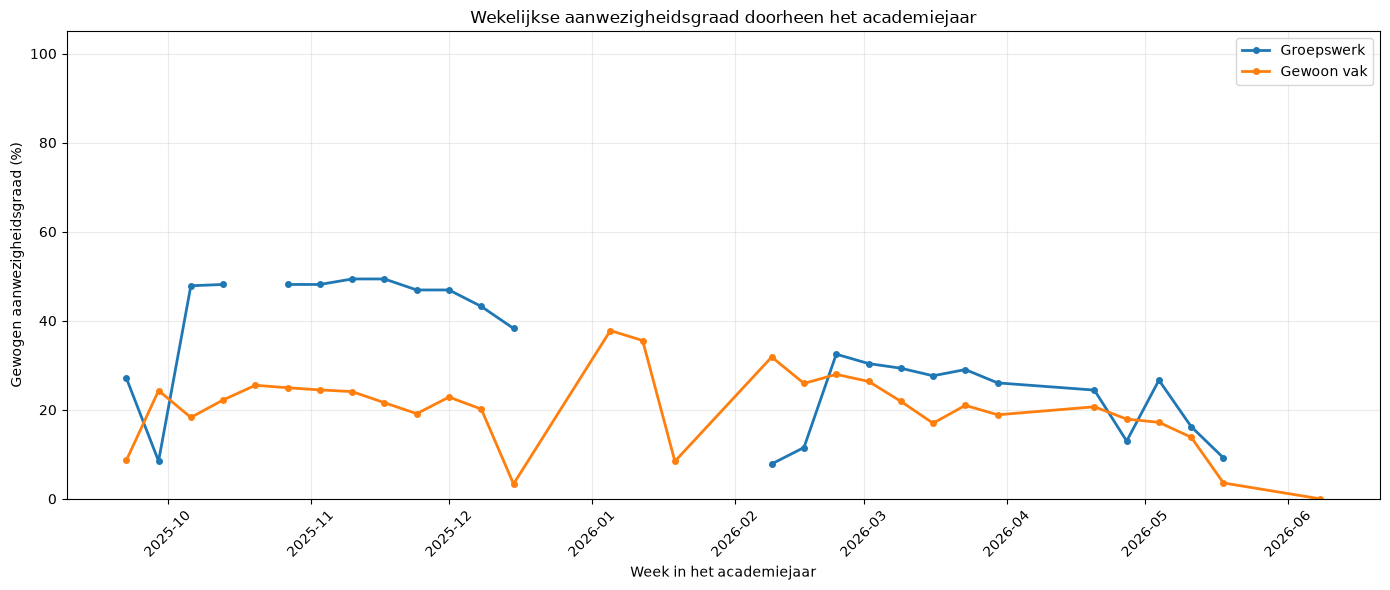

In [67]:
plt.figure(figsize=(14, 6))

for lesson_type in ["Groepswerk", "Gewoon vak"]:
    if lesson_type in weekly_pivot.columns:
        plt.plot(
            weekly_pivot.index,
            weekly_pivot[lesson_type],
            marker="o",
            linewidth=2,
            markersize=4,
            label=lesson_type,
        )

plt.xlabel("Week in het academiejaar")
plt.ylabel("Gewogen aanwezigheidsgraad (%)")
plt.title(
    "Wekelijkse aanwezigheidsgraad doorheen het academiejaar"
)
plt.ylim(0, 105)
plt.grid(alpha=0.25)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

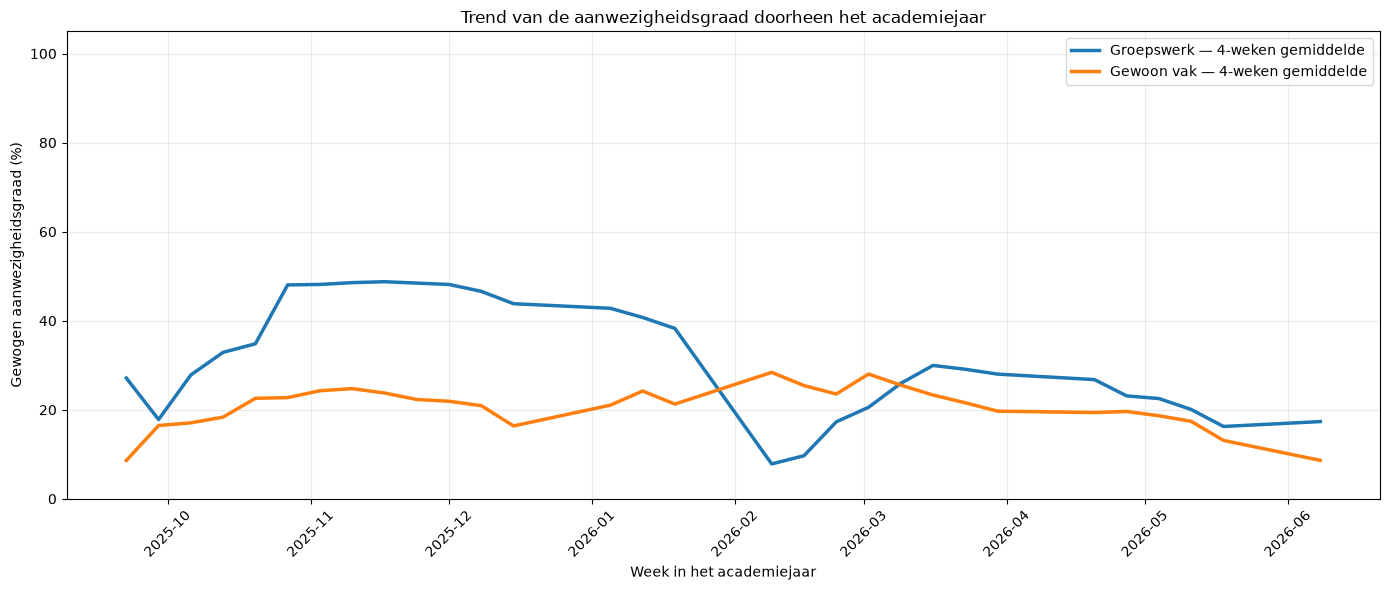

In [68]:
rolling_window = 4

rolling_pivot = weekly_pivot.rolling(
    window=rolling_window,
    min_periods=1,
).mean()

plt.figure(figsize=(14, 6))

for lesson_type in ["Groepswerk", "Gewoon vak"]:
    if lesson_type in rolling_pivot.columns:
        plt.plot(
            rolling_pivot.index,
            rolling_pivot[lesson_type],
            linewidth=2.5,
            label=f"{lesson_type} — {rolling_window}-weken gemiddelde",
        )

plt.xlabel("Week in het academiejaar")
plt.ylabel("Gewogen aanwezigheidsgraad (%)")
plt.title(
    "Trend van de aanwezigheidsgraad doorheen het academiejaar"
)
plt.ylim(0, 105)
plt.grid(alpha=0.25)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

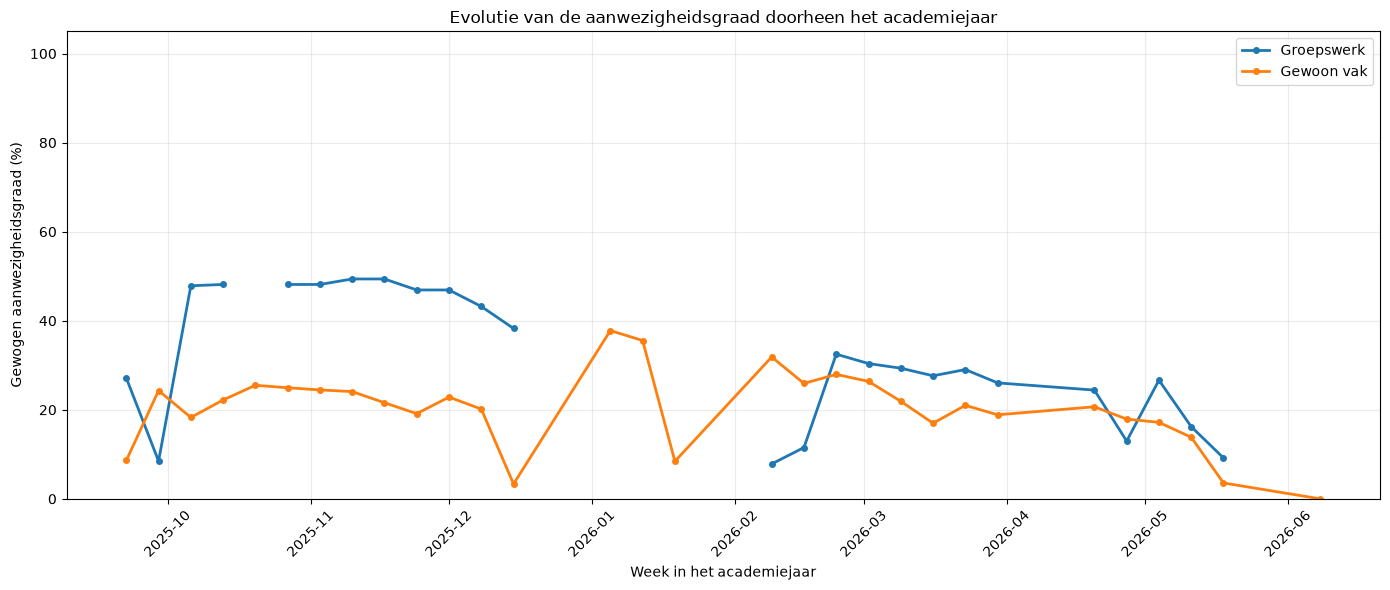

,WeekStart,LessonType,ExpectedStudents,PresentStudents,SessionCount,AttendancePercentage
0,2025-09-22,Gewoon vak,5999,517,70,8.6181
1,2025-09-22,Groepswerk,140,38,2,27.1429
2,2025-09-29,Gewoon vak,6519,1585,74,24.3135
3,2025-09-29,Groepswerk,59,5,1,8.4746
4,2025-10-06,Gewoon vak,6695,1224,72,18.2823
5,2025-10-06,Groepswerk,140,67,2,47.8571
6,2025-10-13,Gewoon vak,6430,1428,73,22.2084
7,2025-10-13,Groepswerk,81,39,1,48.1481
8,2025-10-20,Gewoon vak,6417,1637,73,25.5104
9,2025-10-27,Gewoon vak,6252,1560,75,24.9520


In [69]:
# Weekstart bepalen voor elke sessie
trend_data = valid_session_results.copy()

trend_data["WeekStart"] = (
    trend_data["FullDate"]
    - pd.to_timedelta(
        trend_data["FullDate"].dt.weekday,
        unit="D",
    )
)

# Gewogen aanwezigheid per week en lestype:
# totale aanwezigen / totale verwachte studenten
weekly_trend = (
    trend_data
    .groupby(
        ["WeekStart", "LessonType"],
        observed=True,
        as_index=False,
    )
    .agg(
        ExpectedStudents=("ExpectedStudents", "sum"),
        PresentStudents=("PresentStudents", "sum"),
        SessionCount=("SessionID", "nunique"),
    )
)

weekly_trend["AttendancePercentage"] = np.where(
    weekly_trend["ExpectedStudents"] > 0,
    (
        weekly_trend["PresentStudents"]
        / weekly_trend["ExpectedStudents"]
    ) * 100,
    np.nan,
)

# Week zonder sessies voor één categorie als NaN laten staan
weekly_pivot = weekly_trend.pivot(
    index="WeekStart",
    columns="LessonType",
    values="AttendancePercentage",
).sort_index()

plt.figure(figsize=(14, 6))

for lesson_type in ["Groepswerk", "Gewoon vak"]:
    if lesson_type in weekly_pivot.columns:
        plt.plot(
            weekly_pivot.index,
            weekly_pivot[lesson_type],
            marker="o",
            linewidth=2,
            markersize=4,
            label=lesson_type,
        )

plt.xlabel("Week in het academiejaar")
plt.ylabel("Gewogen aanwezigheidsgraad (%)")
plt.title(
    "Evolutie van de aanwezigheidsgraad doorheen het academiejaar"
)
plt.ylim(0, 105)
plt.grid(alpha=0.25)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

display(weekly_trend.sort_values(["WeekStart", "LessonType"]))

## 19. Kwaliteitscontroles

In [70]:
quality_summary = pd.Series({
    "Roosterfactrijen": len(schedule_raw),
    "Geclassificeerde roosterfactrijen": len(schedule),
    "Niet-gekoppelde unieke vaknamen": len(unmatched_titles),
    "Afgeleide sessies": len(sessions),
    "Sessies met verwachte studenten": len(valid_session_results),
    "Sessies zonder verwachte studenten": (
        session_results["ExpectedStudents"].eq(0).sum()
    ),
    "Sessies zonder aanwezige wifi-gebruikers": (
        valid_session_results["PresentStudents"].eq(0).sum()
    ),
    "Sessies boven 100 procent aanwezigheid": (
        valid_session_results["AttendanceRate"].gt(1).sum()
    ),
})

quality_summary

Roosterfactrijen                            5587
Geclassificeerde roosterfactrijen           5575
Niet-gekoppelde unieke vaknamen                1
Afgeleide sessies                           1801
Sessies met verwachte studenten             1801
Sessies zonder verwachte studenten             0
Sessies zonder aanwezige wifi-gebruikers     207
Sessies boven 100 procent aanwezigheid         0
dtype: int64

In [71]:
lowest_attendance = (
    valid_session_results[[
        "FullDate",
        "SessionID",
        "ClassName",
        "LessonType",
        "SessionStart",
        "SessionEnd",
        "ExpectedStudents",
        "PresentStudents",
        "AttendanceRate",
    ]]
    .sort_values("AttendanceRate")
    .head(30)
)

highest_attendance = (
    valid_session_results[[
        "FullDate",
        "SessionID",
        "ClassName",
        "LessonType",
        "SessionStart",
        "SessionEnd",
        "ExpectedStudents",
        "PresentStudents",
        "AttendanceRate",
    ]]
    .sort_values("AttendanceRate", ascending=False)
    .head(30)
)

print("Laagste aanwezigheidsgraden")
display(lowest_attendance)

print("Hoogste aanwezigheidsgraden")
display(highest_attendance)

Laagste aanwezigheidsgraden


,FullDate,SessionID,ClassName,LessonType,SessionStart,SessionEnd,ExpectedStudents,PresentStudents,AttendanceRate
507,2025-11-27,cybersecurity advanced_20251127_1,Cybersecurity Advanced,Gewoon vak,2025-11-27 19:00:00,2025-11-27 22:00:00,50,0,0.0000
11,2025-12-17,a i voor de bachelorstudent_20251217_1,A.I. voor de bachelorstudent,Gewoon vak,2025-12-17 18:00:00,2025-12-17 20:00:00,104,0,0.0000
472,2025-12-19,costing_20251219_1,Costing,Gewoon vak,2025-12-19 08:15:00,2025-12-19 12:30:00,105,0,0.0000
473,2025-09-23,cybersecurity_20250923_1,Cybersecurity,Gewoon vak,2025-09-23 13:30:00,2025-09-23 17:45:00,129,0,0.0000
1591,2025-10-13,trends in artificial intelligence_20251013_1,Trends in Artificial Intelligence,Gewoon vak,2025-10-13 13:30:00,2025-10-13 15:30:00,75,0,0.0000
74,2026-05-20,big data processing_20260520_2,Big Data Processing,Gewoon vak,2026-05-20 13:30:00,2026-05-20 15:30:00,81,0,0.0000
1228,2026-03-16,operating systems_20260316_1,Operating Systems,Gewoon vak,2026-03-16 10:30:00,2026-03-16 12:30:00,72,0,0.0000
1195,2026-05-19,object oriented software development ii_202605...,Object-oriented Software Development II,Gewoon vak,2026-05-19 10:30:00,2026-05-19 12:30:00,111,0,0.0000
666,2025-11-03,discover the mainframe_20251103_2,Discover the Mainframe,Gewoon vak,2025-11-03 13:30:00,2025-11-03 15:30:00,46,0,0.0000
663,2025-10-27,discover the mainframe_20251027_1,Discover the Mainframe,Gewoon vak,2025-10-27 10:30:00,2025-10-27 12:30:00,46,0,0.0000


Hoogste aanwezigheidsgraden


,FullDate,SessionID,ClassName,LessonType,SessionStart,SessionEnd,ExpectedStudents,PresentStudents,AttendanceRate
453,2025-11-03,costing_20251103_1,Costing,Gewoon vak,2025-11-03 10:30:00,2025-11-03 12:30:00,26,20,0.7692
377,2025-10-17,computer networks ii_20251017_1,Computer Networks II,Gewoon vak,2025-10-17 09:15:00,2025-10-17 12:30:00,32,24,0.7500
383,2025-11-07,computer networks ii_20251107_1,Computer Networks II,Gewoon vak,2025-11-07 09:15:00,2025-11-07 12:30:00,32,24,0.7500
384,2025-11-14,computer networks ii_20251114_1,Computer Networks II,Gewoon vak,2025-11-14 09:15:00,2025-11-14 12:30:00,32,24,0.7500
447,2025-10-20,costing_20251020_1,Costing,Gewoon vak,2025-10-20 10:30:00,2025-10-20 12:30:00,26,19,0.7308
450,2025-10-27,costing_20251027_1,Costing,Gewoon vak,2025-10-27 10:30:00,2025-10-27 12:30:00,26,19,0.7308
1432,2025-10-17,software analysis_20251017_1,Software Analysis,Gewoon vak,2025-10-17 10:30:00,2025-10-17 12:30:00,33,24,0.7273
386,2025-11-21,computer networks ii_20251121_1,Computer Networks II,Gewoon vak,2025-11-21 09:15:00,2025-11-21 12:30:00,32,23,0.7188
379,2025-10-24,computer networks ii_20251024_1,Computer Networks II,Gewoon vak,2025-10-24 09:15:00,2025-10-24 12:30:00,32,23,0.7188
1068,2025-10-15,object oriented software development i_20251015_1,Object-oriented Software Development I,Gewoon vak,2025-10-15 09:15:00,2025-10-15 12:30:00,180,128,0.7111


## 20. Privacyveilige exports

In [72]:
valid_session_results.to_csv(
    OUTPUT_DIR / "course_type_session_attendance.csv",
    index=False,
    encoding="utf-8-sig",
)

metrics_by_type.to_csv(
    OUTPUT_DIR / "metrics_by_lesson_type.csv",
    index=False,
    encoding="utf-8-sig",
)

metrics_by_course.to_csv(
    OUTPUT_DIR / "metrics_by_course.csv",
    index=False,
    encoding="utf-8-sig",
)

lowest_attendance.to_csv(
    OUTPUT_DIR / "lowest_attendance_sessions.csv",
    index=False,
    encoding="utf-8-sig",
)

highest_attendance.to_csv(
    OUTPUT_DIR / "highest_attendance_sessions.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Privacyveilige exports aangemaakt in:")
print(OUTPUT_DIR)

for path in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", path.name)

Privacyveilige exports aangemaakt in:
D:\Documents2\School\26-EP3\DEP\repo\DEP2-2025-2026-groep12\data\processed\CourseTypeAnalysis
- attendance_source_candidates.csv
- attendance_with_lesson_type.csv
- course_type_session_attendance.csv
- group_vs_regular_comparison.csv
- highest_attendance.csv
- highest_attendance_sessions.csv
- lowest_attendance.csv
- lowest_attendance_sessions.csv
- metrics_by_course.csv
- metrics_by_lesson_type.csv
- unmatched_course_titles.csv


## Interpretatie en beperkingen

- Een student wordt als aanwezig beschouwd wanneer minstens één wifi-connectie binnen het start- en eindtijdstip van de sessie valt.
- Een student telt per sessie maximaal één keer mee.
- De verwachte studentenpopulatie is de unie van de studenten die via `BridgeUserSubgroup` gekoppeld zijn aan de subgroepen die voor de sessie ingepland staan.
- Opeenvolgende blokken van hetzelfde vak worden samengevoegd wanneer de onderbreking maximaal `MAX_BREAK_MINUTES` bedraagt.
- Wifi-aanwezigheid blijft een proxy: een verbonden toestel bewijst niet absoluut dat de student de volledige les bijwoonde.
- Studenten zonder toestel, met uitgeschakelde wifi of met ontbrekende warehousekoppelingen kunnen onderschatting veroorzaken.
- Bij System Engineering Lab was een bijkomende afleiding van een vast sessietype nodig. Deze algemene notebook gebruikt de administratief ingeplande subgroep als populatie, omdat die aanpak ook voor gewone vakken en andere groepswerken toepasbaar is.
